# β vs SNR across training time (CelebA ResNet checkpoints)

After running `scripts/slurm_celeba_train_and_calibrate.sh`:
- Load saved `beta_vs_snr_backbone_CelebA_ResNet_epoch{N}.pt` for several epochs.
- Plot **inferred β vs SNR** for LS and ELS at each training time.
- **Sanity check:** generate and show samples from **ResNet (DDIM)**, **ELS**, and **LS** for one or more checkpoints.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path(os.path.abspath("")).resolve().parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
RESULTS_DIR = ROOT / "results" / "channel_theory"
CHECKPOINTS_DIR = ROOT / "checkpoints"
SAVENAME = "backbone_CelebA_ResNet"
EPOCHS_TO_PLOT = [0, 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Load β vs SNR results and plot

In [3]:
def load_beta_vs_snr(epoch: int):
    path = RESULTS_DIR / f"beta_vs_snr_{SAVENAME}_epoch{epoch}.pt"
    if not path.exists():
        return None
    return torch.load(path, weights_only=False)

data_by_epoch = {}
for ep in EPOCHS_TO_PLOT:
    d = load_beta_vs_snr(ep)
    if d is not None:
        data_by_epoch[ep] = d
print("Loaded epochs:", sorted(data_by_epoch.keys()))

Loaded epochs: []


/tmp/ipykernel_38794/86162591.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc="best", fontsize=8)
/tmp/ipykernel_38794/86162591.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc="best", fontsize=8)


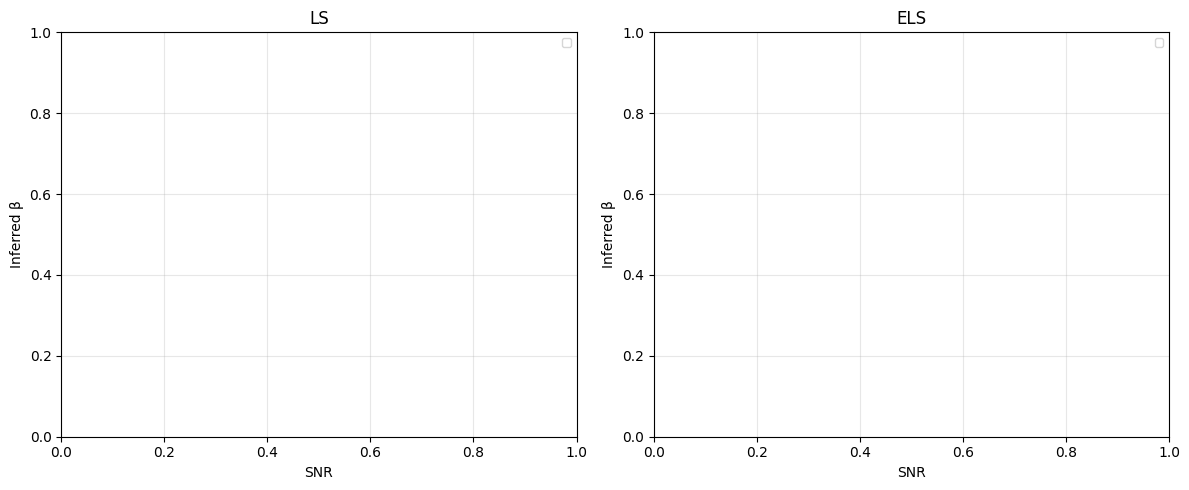

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ep in sorted(data_by_epoch.keys()):
    d = data_by_epoch[ep]
    snr = np.array(d["snr"])
    beta_ls = np.array(d["beta_ls"])
    beta_els = np.array(d["beta_els"])
    err_lo_ls = np.array(d.get("beta_ls_err_lo", [None] * len(snr)))
    err_hi_ls = np.array(d.get("beta_ls_err_hi", [None] * len(snr)))
    err_lo_els = np.array(d.get("beta_els_err_lo", [None] * len(snr)))
    err_hi_els = np.array(d.get("beta_els_err_hi", [None] * len(snr)))
    
    mask_ls = np.isfinite(beta_ls) & (np.array(beta_ls) != None)
    mask_ls = np.array([x is not None and np.isfinite(x) for x in beta_ls])
    mask_els = np.array([x is not None and np.isfinite(x) for x in beta_els])

    if np.any(mask_ls):
        bl = np.array([float(b) if b is not None else np.nan for b in beta_ls])
        elo = np.array([float(e) if e is not None else np.nan for e in err_lo_ls])
        ehi = np.array([float(e) if e is not None else np.nan for e in err_hi_ls])
        axes[0].plot(snr, bl, "o-", label=f"epoch {ep}", alpha=0.8)
        if np.any(np.isfinite(elo)) or np.any(np.isfinite(ehi)):
            axes[0].fill_between(snr, bl - np.nan_to_num(elo), bl + np.nan_to_num(ehi), alpha=0.2)
    if np.any(mask_els):
        be = np.array([float(b) if b is not None else np.nan for b in beta_els])
        elo = np.array([float(e) if e is not None else np.nan for e in err_lo_els])
        ehi = np.array([float(e) if e is not None else np.nan for e in err_hi_els])
        axes[1].plot(snr, be, "o-", label=f"epoch {ep}", alpha=0.8)
        if np.any(np.isfinite(elo)) or np.any(np.isfinite(ehi)):
            axes[1].fill_between(snr, be - np.nan_to_num(elo), be + np.nan_to_num(ehi), alpha=0.2)

axes[0].set_xlabel("SNR")
axes[0].set_ylabel("Inferred β")
axes[0].set_title("LS")
axes[0].legend(loc="best", fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("SNR")
axes[1].set_ylabel("Inferred β")
axes[1].set_title("ELS")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "results" / "channel_theory" / "beta_vs_snr_by_epoch.pdf", bbox_inches="tight")
plt.show()

## 2. Sanity check: generated images from ResNet, ELS, and LS

In [5]:
from src.models import DDIM, MinimalResNet
from src.utils.data import get_dataset
from src.utils.idealscore import (
    LocalEquivScoreModule,
    LocalScoreModule,
    ScheduledScoreMachine,
)
from src.utils.noise_schedules import cosine_noise_schedule

def build_resnet_ddim(ckpt_path, device, in_channels=3, image_size=32):
    ddim = torch.load(ckpt_path, map_location=device, weights_only=False)
    ddim.eval()
    return ddim

def build_els_machine(dataset, scales_median_path, device, max_samples=500, image_size=32, in_channels=3):
    schedule = cosine_noise_schedule
    scales_data = torch.load(scales_median_path, weights_only=False)
    scales = [int(s) for s in (scales_data.int().numpy() if isinstance(scales_data, torch.Tensor) else scales_data)]
    mod = LocalEquivScoreModule(
        dataset, batch_size=32, image_size=image_size, channels=in_channels,
        schedule=schedule, max_samples=max_samples
    )
    machine = ScheduledScoreMachine(mod, in_channels=in_channels, noise_schedule=schedule, score_backbone=True, scales=scales)
    machine.to(device).eval()
    return machine

def build_ls_machine(dataset, scales_median_path, device, max_samples=500, image_size=32, in_channels=3):
    schedule = cosine_noise_schedule
    scales_data = torch.load(scales_median_path, weights_only=False)
    scales = [int(s) for s in (scales_data.int().numpy() if isinstance(scales_data, torch.Tensor) else scales_data)]
    mod = LocalScoreModule(
        dataset, image_size=image_size, batch_size=min(64, len(dataset)), schedule=schedule, max_samples=max_samples
    )
    machine = ScheduledScoreMachine(mod, in_channels=in_channels, noise_schedule=schedule, score_backbone=True, scales=scales)
    machine.to(device).eval()
    return machine

In [6]:
# Pick one or more checkpoints for sanity-check generation
EPOCH_SAMPLES = 5  # e.g. early and late
NUM_SAMPLES = 8
NSTEPS = 20
MAX_SAMPLES_IDEAL = 500

dataset, metadata = get_dataset("celeba", root=str(ROOT / "data"))
in_channels = metadata["num_channels"]
image_size = metadata["image_size"]

ckpt_path = CHECKPOINTS_DIR / f"{SAVENAME}_epoch{EPOCH_SAMPLES}.pt"
scale_els_path = CHECKPOINTS_DIR / f"scales_{SAVENAME}_epoch{EPOCH_SAMPLES}_ELS_median.pt"
scale_ls_path = CHECKPOINTS_DIR / f"scales_{SAVENAME}_epoch{EPOCH_SAMPLES}_LS_median.pt"

if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
if not scale_els_path.exists() or not scale_ls_path.exists():
    raise FileNotFoundError(f"Scale files not found for epoch {EPOCH_SAMPLES}. Run calibration first.")

ddim = build_resnet_ddim(str(ckpt_path), device, in_channels, image_size)
ddim.to(device).eval()
machine_els = build_els_machine(dataset, str(scale_els_path), device, MAX_SAMPLES_IDEAL, image_size, in_channels)
machine_ls = build_ls_machine(dataset, str(scale_ls_path), device, MAX_SAMPLES_IDEAL, image_size, in_channels)

Files already downloaded and verified


FileNotFoundError: Scale files not found for epoch 5. Run calibration first.

In [ ]:
torch.manual_seed(123)
seeds = torch.randn(NUM_SAMPLES, in_channels, image_size, image_size, device=device)

with torch.no_grad():
    resnet_imgs = ddim.sample(batch_size=NUM_SAMPLES, x=seeds.clone(), nsteps=NSTEPS, device=device)

els_imgs = []
ls_imgs = []
with torch.no_grad():
    for i in range(NUM_SAMPLES):
        seed_i = seeds[i : i + 1]
        els_imgs.append(machine_els(seed_i, device=device).cpu())
        ls_imgs.append(machine_ls(seed_i, device=device).cpu())
resnet_imgs = resnet_imgs.cpu()
els_imgs = torch.cat(els_imgs, dim=0)
ls_imgs = torch.cat(ls_imgs, dim=0)

In [ ]:
def denorm(x):
    x = x.clone()
    x = (x + 1) / 2
    return x.clamp(0, 1)

fig, axes = plt.subplots(3, NUM_SAMPLES, figsize=(2 * NUM_SAMPLES, 6))
for j in range(NUM_SAMPLES):
    axes[0, j].imshow(denorm(resnet_imgs[j]).permute(1, 2, 0).numpy())
    axes[0, j].set_axis_off()
    axes[1, j].imshow(denorm(els_imgs[j]).permute(1, 2, 0).numpy())
    axes[1, j].set_axis_off()
    axes[2, j].imshow(denorm(ls_imgs[j]).permute(1, 2, 0).numpy())
    axes[2, j].set_axis_off()
axes[0, 0].set_ylabel("ResNet (DDIM)", fontsize=10)
axes[1, 0].set_ylabel("ELS", fontsize=10)
axes[2, 0].set_ylabel("LS", fontsize=10)
plt.suptitle(f"CelebA samples at epoch {EPOCH_SAMPLES} (same seed order)", fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "results" / "channel_theory" / f"samples_epoch{EPOCH_SAMPLES}.pdf", bbox_inches="tight")
plt.show()